In [1]:
import os
import codecs
# point this at wherever you extracted the archive on your machine
DATA_ROOT = "/home/praneeth/ML_lab_7/20news-bydate" # <- your actual path
TRAIN_DIR = os.path.join(DATA_ROOT, "20news-bydate-train")
TEST_DIR = os.path.join(DATA_ROOT, "20news-bydate-test")
class_folder=sorted(os.listdir(TRAIN_DIR)) # should list the 20 class folders
print(class_folder)
ALPHA=1

['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [2]:
file = open('en.txt','r')
words = file.read()
stop_words=set(words.split())
file.close()

In [3]:
def tokenize(text):
    text_body = text.split('\n\n')[1]
    text_words=text_body.lower().split()
    words=[]
    for word in text_words:
        word = word.strip(".,!?()[]:;")
        if word.isalpha() and len(word)>1:
            if word not in stop_words:
                words.append(word)
    return words
    

In [4]:
from collections import Counter
import math

def predict_class(doc,classes,probability_cls,probability_word):
    class_predict = {}
    word_counts = Counter(doc)
    for cls_lbl in range(len(classes)):

        score = math.log(
            probability_cls[str(cls_lbl+1)]
        )
        for word, count in word_counts.items():
            index = word + str(cls_lbl+1)
            if index in probability_word:
                score += count * math.log(
                    probability_word[index]
                )
        class_predict[str(cls_lbl+1)] = score
    return class_predict

In [5]:
tasks = {"task1": ["sci.med", "sci.space"],"task2": ["comp.sys.ibm.pc.hardware","comp.sys.mac.hardware"],
    "task3": ["politics", "religion"],
    "task4": ["politics", "sci"],
    "task5": ["politics", "rec", "religion", "sci"]
}
def expand_class(cls):
    if cls == "politics":
        return [
            "talk.politics.misc",
            "talk.politics.guns",
            "talk.politics.mideast"
        ]
    if cls == "religion":
        return [
            "talk.religion.misc",
            "alt.atheism",
            "soc.religion.christian"
        ]
    if cls == "rec":
        return [
            "rec.autos",
            "rec.motorcycles",
            "rec.sport.baseball",
            "rec.sport.hockey"
        ]
    if cls == "sci":
        return [
            "sci.crypt",
            "sci.electronics",
            "sci.med",
            "sci.space"
        ]
    if cls == "comp":
        return [
            "comp.graphics",
            "comp.os.ms-windows.misc",
            "comp.sys.ibm.pc.hardware",
            "comp.sys.mac.hardware",
            "comp.windows.x"
        ]
    return [cls]

In [6]:
def NB_binary(folders,TRAIN_DIR,TEST_DIR):
    train_list_1=[]
    classes=len(folders)
    train_doc_count_1=[]
    for cls in folders:
        class_tokens = []
        doc_count = 0
        actual_folders = expand_class(cls)

        for folder in actual_folders:
            file_path = os.path.join(TRAIN_DIR,folder)
            file_list= os.listdir(file_path)
            doc_count += len(file_list)
            for file in file_list:
                file_path_2=os.path.join(file_path,file)
                F = codecs.open(file_path_2,'r',encoding='utf-8',errors='ignore')
                content=F.read()
                # print(content)
                tokens=tokenize(content)
                for i in tokens:
                    class_tokens.append(i)
        train_list_1.append(class_tokens)
        train_doc_count_1.append(doc_count)

    v=[]
    for i in train_list_1:
        v+=i
    v=set(v)
    V=len(v)
    probability_word={}
    for word in v:
        for cls in range(classes):
            wrd_list=train_list_1[cls]
            word_count=wrd_list.count(word)
            total_word=len(wrd_list)
            probability=(word_count+ALPHA)/(total_word + ALPHA*V)
            index=str(word)+str(cls+1)
            probability_word[index]=probability

    probability_cls={}
    total_docs=sum(train_doc_count_1)
    for cls in range(classes):
        p=train_doc_count_1[cls]/total_docs
        index=str(cls+1)
        probability_cls[index]=p

    test_list = []
    test_labels = []
    
    for cls, folder in enumerate(folders):
    
        actual_folders = expand_class(folder)

        for folder in actual_folders:
    
            file_path = os.path.join(TEST_DIR, folder)
            file_list = os.listdir(file_path)
    
            for file in file_list:
    
                file_path_2 = os.path.join(file_path, file)
    
                F = codecs.open(
                    file_path_2,
                    'r',
                    encoding='utf-8',
                    errors='ignore'
                )
    
                content = F.read()
                tokens = tokenize(content)
    
                test_list.append(tokens)
                test_labels.append(str(cls + 1))

    predictions = []
    
    for doc in test_list:
        scores = predict_class(doc,folders,probability_cls,probability_word)
        predicted_class = max(scores, key=scores.get)
        predictions.append(predicted_class)
    
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Accuracy
    accuracy = accuracy_score(test_labels, predictions)
    print("Accuracy:", accuracy)

    # Precision, Recall, F1 for every class
    print("\nClassification Report:")
    print(classification_report(
        test_labels,
        predictions,
        target_names=folders
    ))

    # Confusion Matrix
    confusion = confusion_matrix(test_labels, predictions)

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        confusion,
        annot=True,
        fmt="d",
        xticklabels=folders,
        yticklabels=folders
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.title("Confusion Matrix - Multinomial Naive Bayes")
    plt.tight_layout()
    plt.show()

## 1. Naive Bayes Classification

Accuracy: 0.8569620253164557

Classification Report:
              precision    recall  f1-score   support

     sci.med       0.85      0.86      0.86       396
   sci.space       0.86      0.85      0.86       394

    accuracy                           0.86       790
   macro avg       0.86      0.86      0.86       790
weighted avg       0.86      0.86      0.86       790



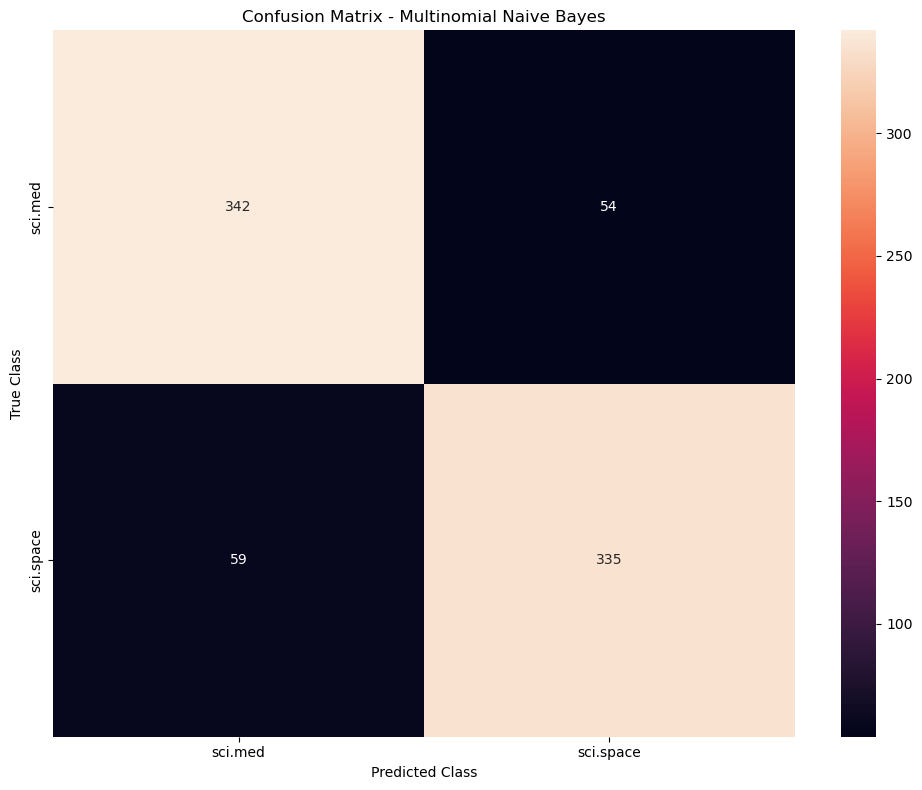

In [7]:
## (i) sci.med vs sci.space
NB_binary(tasks["task1"], TRAIN_DIR, TEST_DIR)

Accuracy: 0.7773487773487774

Classification Report:
                          precision    recall  f1-score   support

comp.sys.ibm.pc.hardware       0.75      0.84      0.79       392
   comp.sys.mac.hardware       0.81      0.71      0.76       385

                accuracy                           0.78       777
               macro avg       0.78      0.78      0.78       777
            weighted avg       0.78      0.78      0.78       777



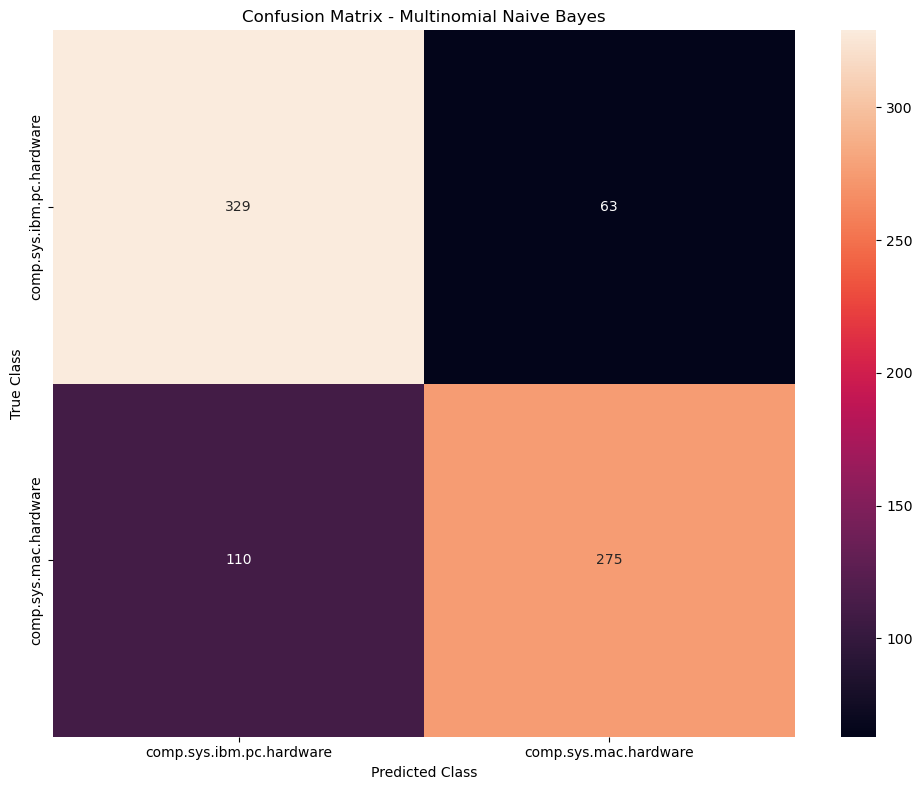

In [8]:
## (ii) comp.sys.ibm.pc.hardware vs comp.sys.mac.hardware
NB_binary(tasks["task2"], TRAIN_DIR, TEST_DIR)

Accuracy: 0.8300297324083251

Classification Report:
              precision    recall  f1-score   support

    politics       0.83      0.84      0.84      1050
    religion       0.83      0.82      0.82       968

    accuracy                           0.83      2018
   macro avg       0.83      0.83      0.83      2018
weighted avg       0.83      0.83      0.83      2018



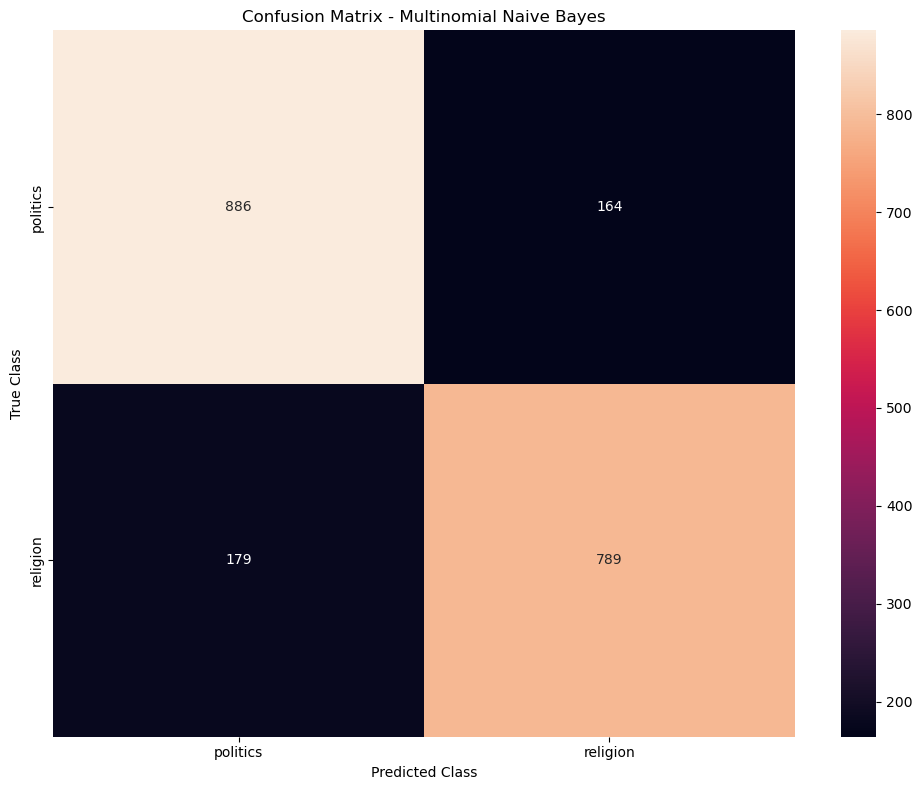

In [9]:
##(iii) politics vs religion
NB_binary(tasks["task3"], TRAIN_DIR, TEST_DIR)

Accuracy: 0.8550779764168885

Classification Report:
              precision    recall  f1-score   support

    politics       0.84      0.79      0.81      1050
         sci       0.87      0.90      0.88      1579

    accuracy                           0.86      2629
   macro avg       0.85      0.84      0.85      2629
weighted avg       0.85      0.86      0.85      2629



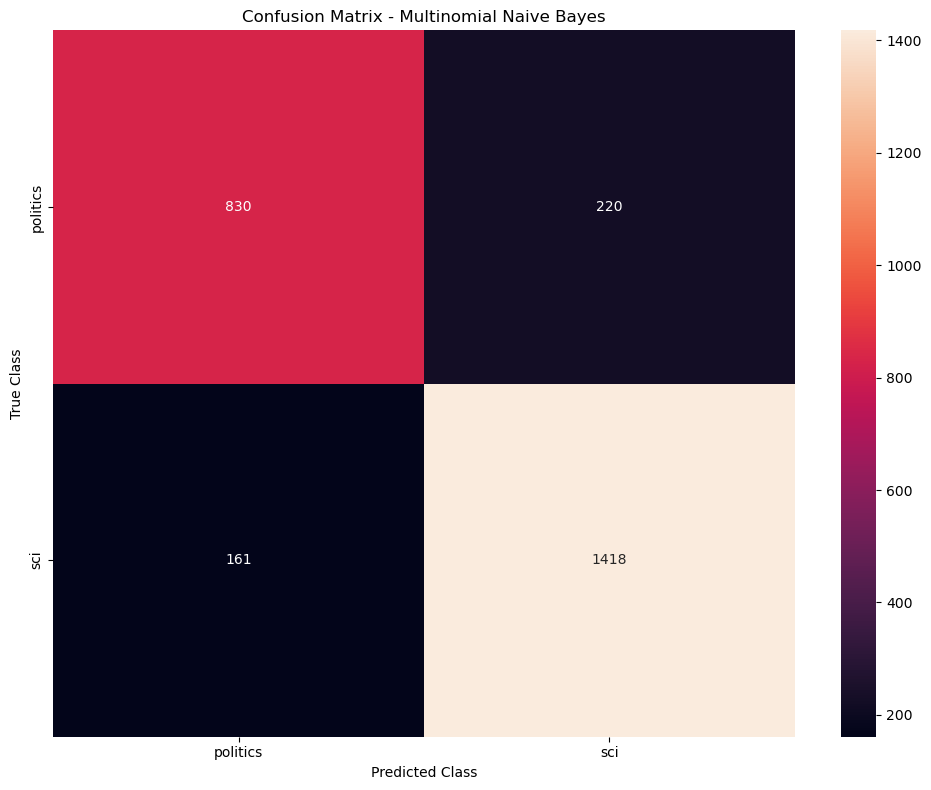

In [10]:
##(iv) politics vs sci
NB_binary(tasks["task4"], TRAIN_DIR, TEST_DIR)

Accuracy: 0.7559282822440717

Classification Report:
              precision    recall  f1-score   support

    politics       0.74      0.67      0.70      1050
         rec       0.72      0.87      0.79      1590
    religion       0.77      0.71      0.74       968
         sci       0.82      0.72      0.77      1579

    accuracy                           0.76      5187
   macro avg       0.76      0.74      0.75      5187
weighted avg       0.76      0.76      0.75      5187



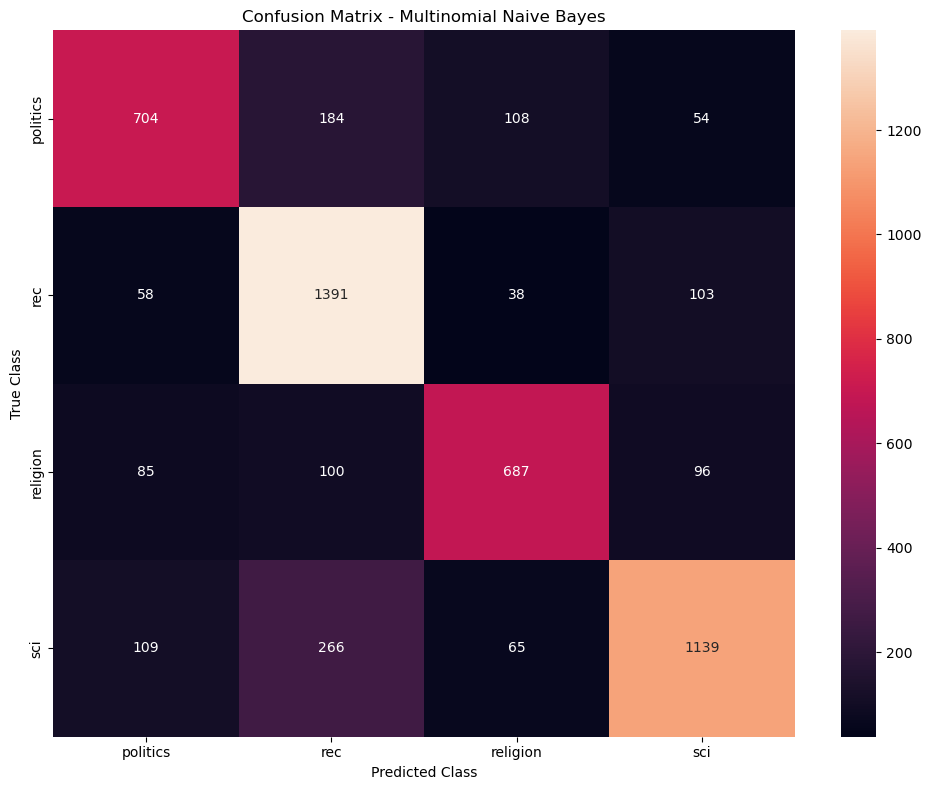

In [11]:
#(v) politics vs rec vs religion vs sci
NB_binary(tasks["task5"], TRAIN_DIR, TEST_DIR)

## C. Interpret the classifiers and explain in your own words the behavior of these classifiers
Ans:  Multinomial naive bayes classifier seperates the classes based on the frequency of the words that appear in each class. Naive bayes runs on the assumption that the words are conditionally independent given the class but in real world this assumption doesn't hold completely.

(i) gave a fairly high accuracy because the classes have fairly distinct vocabularies sci.med mostly have words related to medicine whereas sci.space has words realted to space these are 2 very different domains but they fall into science which maybe the reason they lose some accuracy due to words used together in science. and hence the f1 score precision and recall are high and similar.

(ii)The NB classifier give an accuracy of 77%, this implies it's able to distinguish between the classes fairly well but the over lap of words is high since the hardware might use words such as memory,cpu,hard drive commonly hence reducing the accuracy. the recall is high for ibm implying the classifier performs well for ibm.

(iii) The classifier achieves a accuracy of 83.00% both classes have a precision of 0.83, the recall is higher for politices at (0.84) than for religion at 0.82. classifier is slightly better at identifying the actual politics documents than religion overall F1score shows the classifier performs well across both.

(iv) The classifier achieves a accuracy of 85.51% sci has higher recall implies most of the sci documents are classified correctly as compared to politics

(v)This has a accuracy of 75.59% which is lower than the binary ones, This makes sense since the classifier has to distinguish between 4 classes with more overlap/dependency of vocabularies.rec has the highest recall of 0.87 and politics has 0.67.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [13]:
#TF(t,d) = NUmber of times term t appears in document d / total number of terms in d
#IDF(t,D) = log(total number of documents in corpus D/number of documents containg term t)
def load_docs(folders,DATA_DIR):
    documents=[]
    labels=[]
    for cls,folder in enumerate(folders):
        actual_folders=expand_class(folder)
        for folder_2 in actual_folders:
            file_path=os.path.join(DATA_DIR,folder_2)
            file_list=os.listdir(file_path)
            for file in file_list:
                file_path_2=os.path.join(file_path,file)
                F=codecs.open(file_path_2,'r',encoding='utf-8',errors='ignore')
                content=F.read()
                tokens=tokenize(content)
                documents.append(tokens)
                labels.append(cls)
    return documents,labels

def TF_IDF_fit(documents):
        
    v=[]##vocabulary
    for doc in documents:
        v+=doc
    v=sorted(set(v))
    vector_size=len(v)
    
    #IDF
    N=len(documents)
    idf={}
    for word in v:
        count=0
        for doc in documents:
            if word in doc:
                count+=1
        idf[word]=math.log(N/(1+count))
    
    return v,idf


def TF_IDF_transform(documents,v,idf):
        
    vector_set=[]
    
    ##TF
    for doc in documents:
        vector=[]
        total_t_d=len(doc)
        word_count={}
        for term in doc:
            if term in word_count:
                word_count[term]+=1
            else:
                word_count[term]=1
        
        for term in v:
            if term in word_count:
                TF=word_count[term]/total_t_d
            else:
                TF=0
            
            vector.append(TF*idf[term])
        vector_set.append(vector)
    
    return vector_set

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix
def LR_classifier(folders,TRAIN_DIR,TEST_DIR):
    train_documents,train_labels=load_docs(folders,TRAIN_DIR)
    test_documents,test_labels=load_docs(folders,TEST_DIR)
    v,idf=TF_IDF_fit(train_documents)
    X_train=TF_IDF_transform(train_documents,v,idf)
    X_test=TF_IDF_transform(test_documents,v,idf)
    model=LogisticRegression()
    model.fit(X_train,train_labels)
    predictions=model.predict(X_test)
    accuracy = accuracy_score(test_labels, predictions)
    print("Accuracy:", accuracy)
    print("Classification Report:")
    print(classification_report(test_labels,predictions,target_names=folders))
    print("Confusion Matrix:")
    confusion=confusion_matrix(test_labels,predictions)
    plt.figure(figsize=(10, 8))

    sns.heatmap(
        confusion,
        annot=True,
        fmt="d",
        xticklabels=folders,
        yticklabels=folders
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.title("Confusion Matrix - Multinomial Naive Bayes")
    plt.tight_layout()
    plt.show()

Accuracy: 0.8607594936708861
Classification Report:
              precision    recall  f1-score   support

     sci.med       0.84      0.90      0.87       396
   sci.space       0.89      0.82      0.86       394

    accuracy                           0.86       790
   macro avg       0.86      0.86      0.86       790
weighted avg       0.86      0.86      0.86       790

Confusion Matrix:


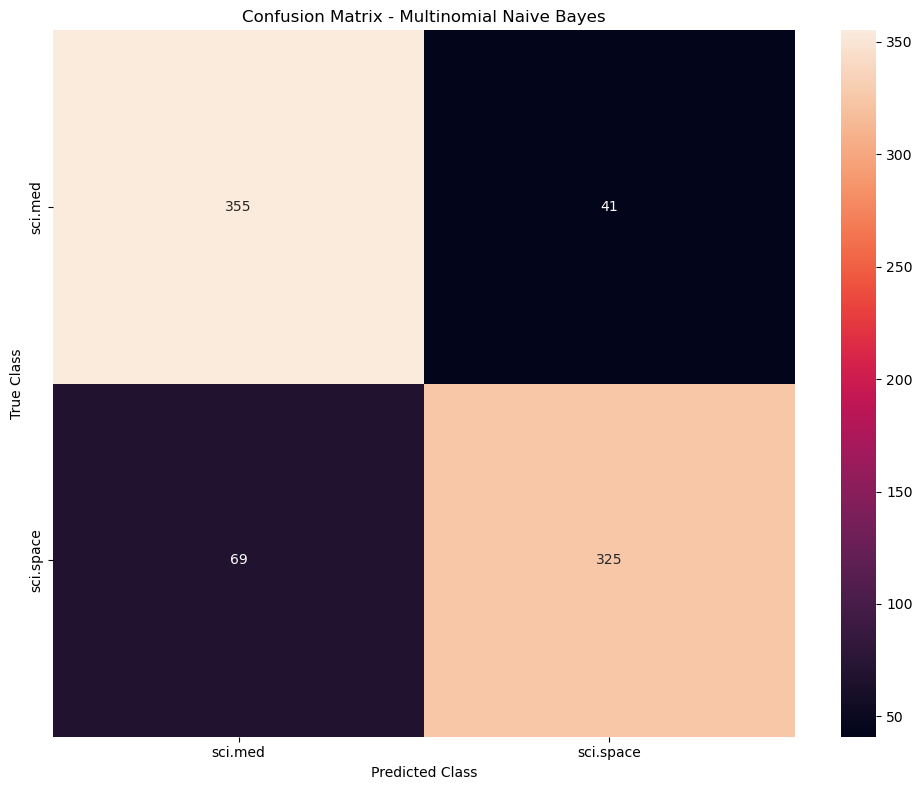

In [15]:
LR_classifier(tasks["task1"],TRAIN_DIR,TEST_DIR)

Accuracy: 0.7747747747747747
Classification Report:
                          precision    recall  f1-score   support

comp.sys.ibm.pc.hardware       0.74      0.86      0.79       392
   comp.sys.mac.hardware       0.83      0.68      0.75       385

                accuracy                           0.77       777
               macro avg       0.78      0.77      0.77       777
            weighted avg       0.78      0.77      0.77       777

Confusion Matrix:


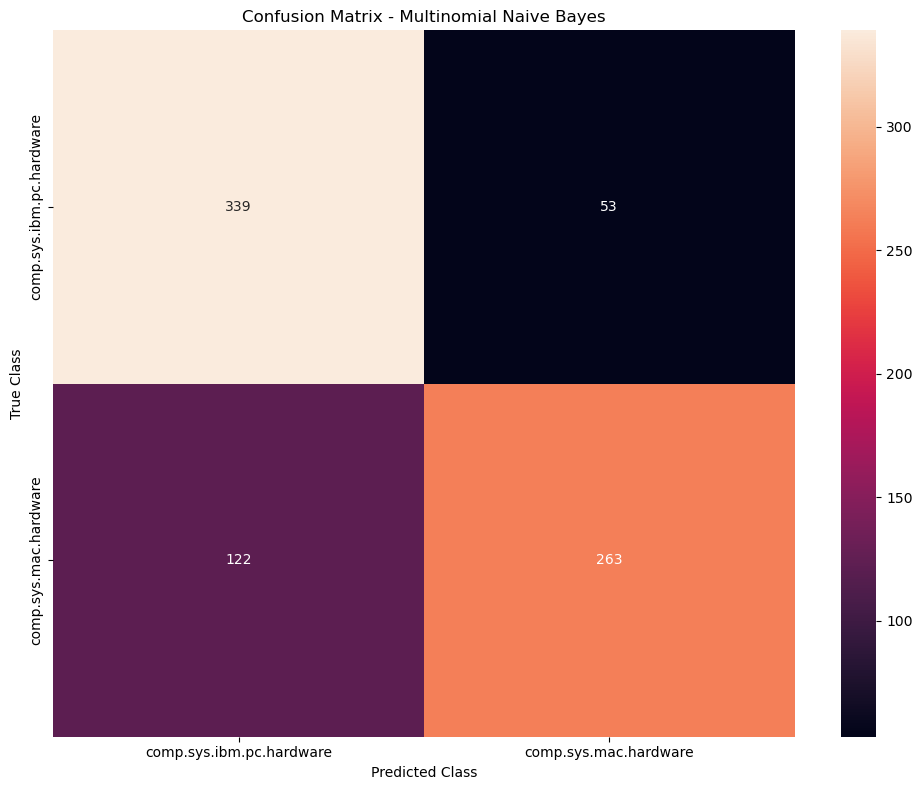

In [16]:
LR_classifier(tasks["task2"],TRAIN_DIR,TEST_DIR)

Accuracy: 0.8221010901883052
Classification Report:
              precision    recall  f1-score   support

    politics       0.80      0.88      0.84      1050
    religion       0.85      0.76      0.80       968

    accuracy                           0.82      2018
   macro avg       0.83      0.82      0.82      2018
weighted avg       0.82      0.82      0.82      2018

Confusion Matrix:


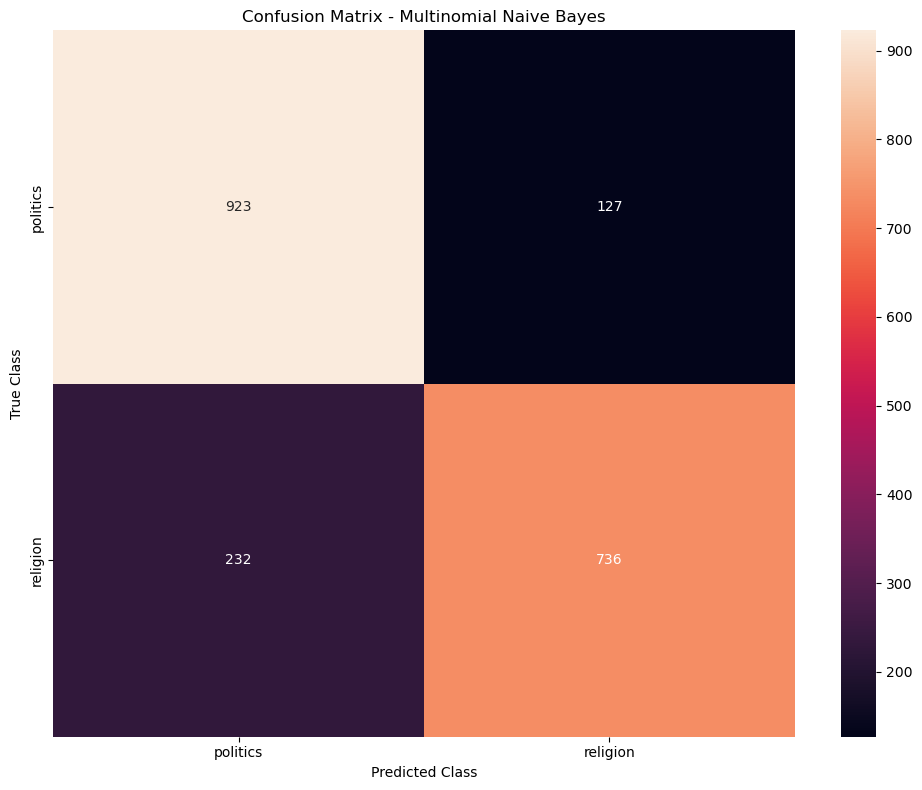

In [17]:
LR_classifier(tasks["task3"],TRAIN_DIR,TEST_DIR)

Accuracy: 0.8288322556104983
Classification Report:
              precision    recall  f1-score   support

    politics       0.85      0.69      0.76      1050
         sci       0.82      0.92      0.87      1579

    accuracy                           0.83      2629
   macro avg       0.83      0.81      0.81      2629
weighted avg       0.83      0.83      0.83      2629

Confusion Matrix:


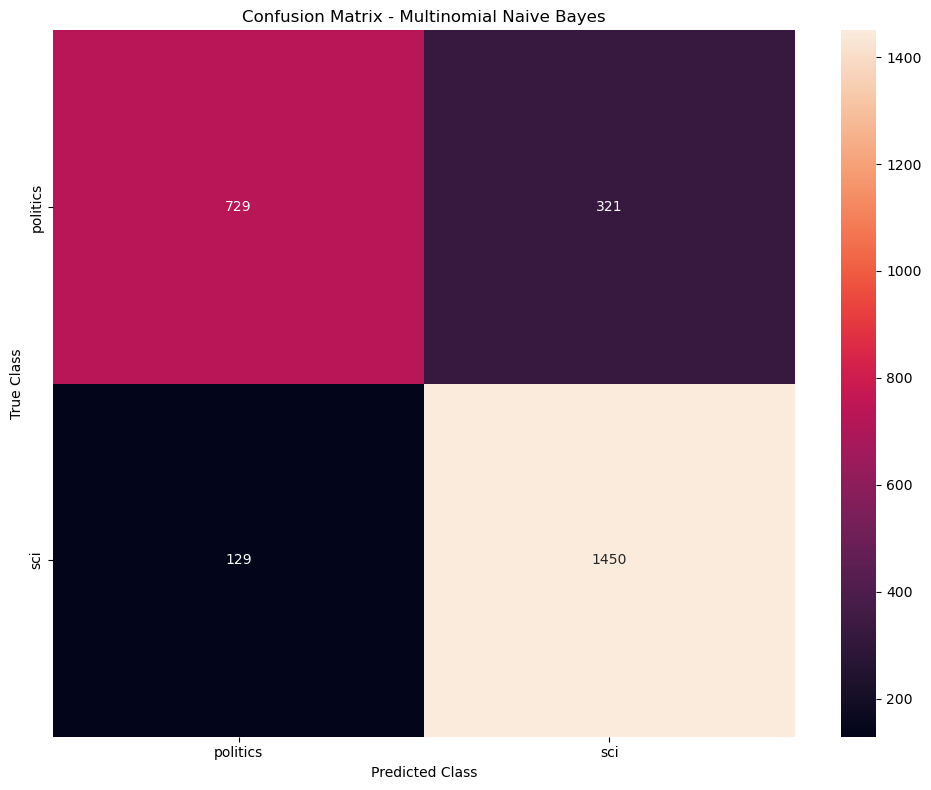

In [18]:
LR_classifier(tasks["task4"],TRAIN_DIR,TEST_DIR)

In [ ]:
LR_classifier(tasks["task5"],TRAIN_DIR,TEST_DIR)

Ans:The LR_classifier performs better tha NB only on the first task with accuracy of 0.861
    performance is generally comparable but the last coudn't be evaluated cause the calculation is too heavy